# 1. Project Goal

## Business Context & Problem
A Portuguese banking institution conducted direct marketing campaigns based on phone calls. Frequently, more than one contact to the same client was necessary to assess whether the product (bank term deposit) would be subscribed.

The business problem is to **predict whether a bank customer will subscribe to a term deposit**.

- **Target Variable**: `y`
- **Values**: `yes` / `no`
- **Machine Learning Task**: Binary Classification

---

## Project Goal
The focus of this project is **not model complexity**.

The goal is to understand how **data preparation** affects the quality and realism of a machine learning model.

Topics that are explored throughout this project:
- **duplicates**
- **missing and unknown values**
- **outliers**
- **data leakage**
- **scaling**
- **categorical encoding**
- **class imbalance**
- **feature creation**
- **feature selection**
- **permutation importance**

---

## Step 2 Scope
In this step, we implement:
1. **Preserve Raw Dataset & Prepare Features/Target**
2. **Handle Potential Data Leakage (`duration`)**
3. **Stratified Train/Test Split**
4. **Principled Treatment of "Unknown" Categories**
5. **SimpleImputer for Categorical Features**

> **Strict Constraints**:
> - **DO NOT perform categorical encoding yet.**
> - **DO NOT perform feature scaling yet.**
> - **DO NOT perform class balancing yet.**
> - **DO NOT train any machine learning models yet.**

In [1]:
import io
import urllib.request
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Display formatting options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# 2. Load Dataset

We load the official Bank Marketing dataset from the **UCI Machine Learning Repository**.

We use the main `bank-full.csv` dataset, which contains approximately 45,211 rows and includes the target column `y`.

In [2]:
# Download and load bank-full.csv directly from official UCI archive
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

req = urllib.request.Request(url, headers=headers)
with urllib.request.urlopen(req) as response:
    zip_bytes = io.BytesIO(response.read())

with zipfile.ZipFile(zip_bytes) as archive:
    with archive.open("bank-full.csv") as csv_file:
        df = pd.read_csv(csv_file, sep=";")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())
print("\nColumn Names:")
print(list(df.columns))

Dataset Shape: (45211, 17)

First 5 Rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no



Column Names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


### Observations on Dataset Loading
- The dataset successfully loaded with **45,211 rows** and **17 columns**, matching the benchmark UCI `bank-full` specification.
- The target column `y` is present.
- The 17 columns capture demographic attributes (such as `age`, `job`, `marital`, `education`, `balance`, `housing`, `loan`) and campaign contact history (such as `contact`, `day`, `month`, `duration`, `campaign`, `pdays`, `previous`, `poutcome`).

# 3. Understand the Dataset

Before performing any transformations, we inspect data types, feature representations, summary statistics, and categorical cardinality.

In [3]:
# Display structural information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


### Observations on df.info()
- The dataset has 17 columns and 45,211 entries.
- All columns currently show 45,211 non-null entries under standard null checks.
- Types consist of 7 integer features and 10 string/object features.

In [4]:
# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [col for col in df.columns if col not in numerical_cols]

print(f"Numerical Columns ({len(numerical_cols)}):")
print(numerical_cols)

print(f"\nCategorical Columns ({len(categorical_cols)}):")
print(categorical_cols)

Numerical Columns (7):
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical Columns (10):
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


### Feature Categorization
- **Numerical columns (7)**: `age`, `balance`, `day`, `duration`, `campaign`, `pdays`, `previous`
- **Categorical columns (10)**: `job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `poutcome`, `y`

In [5]:
# Basic numerical statistics
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### Observations on Basic Numerical Statistics
- `age`: Ranges from 18 to 95 years, with a median of 39.0 and mean of ~40.9 years.
- `balance`: Mean is 1,362.27, while the median is only 448.0, with values ranging from -8,019 to 102,127, indicating heavy positive skewness.
- `duration`: Call duration averages 258.16 seconds (~4.3 minutes), with median 180 seconds, maxing at 4,918 seconds (~82 minutes).
- `campaign`: Number of contacts during this campaign averages 2.76, median 2.0, with a maximum of 63.
- `pdays`: Median is -1.0 (over 75% of rows are -1.0, representing clients not previously contacted).
- `previous`: Median is 0.0, max is 275 contacts prior to this campaign.

In [6]:
# Display number of unique values per categorical column
unique_counts = df[categorical_cols].nunique()
print("Number of Unique Values per Categorical Column:")
print(unique_counts)

Number of Unique Values per Categorical Column:
job          12
marital       3
education     4
default       2
housing       2
loan          2
contact       3
month        12
poutcome      4
y             2
dtype: int64


### Observations on Categorical Columns
- **Binary Features (2 unique values)**: `default`, `housing`, `loan`, and target `y` (`yes` / `no`).
- **Low to Moderate Cardinality (3–4 unique values)**: `marital` (3 values), `education` (4 values), `contact` (3 values), `poutcome` (4 values).
- **Higher Cardinality (12 unique values)**: `job` (12 categories), `month` (12 months).
- **Important**: No categorical encoding has been applied yet.

# 4. Data Quality Audit

We perform inspection only. We do **NOT** modify the dataset, drop rows, or impute values in this step.

### Duplicates

In [7]:
# Check for duplicate rows
print("Duplicate rows count:", df.duplicated().sum())

Duplicate rows count: 0


### Observations on Duplicates
- `df.duplicated().sum()` returns **0**.
- There are no duplicate rows in the raw dataset. We do not drop any duplicates.

### Missing Values

In [8]:
# Check for standard missing values (NaN)
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing (NaN) values:", df.isnull().sum().sum())

Missing values per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Total missing (NaN) values: 0


### Observations on Missing Values
- Total missing (`NaN`) values across the entire dataset is **0**.
- Standard missing value checks do not reveal any explicit null entries.

### "Unknown" Categories

In [9]:
# Inspect all categorical columns for placeholder "unknown" entries
unknown_records = []
for col in categorical_cols:
    count = (df[col] == "unknown").sum()
    pct = (count / len(df)) * 100
    unknown_records.append({
        "column": col,
        "unknown_count": count,
        "unknown_percentage": round(pct, 2)
    })

unknown_df = pd.DataFrame(unknown_records).sort_values(by="unknown_percentage", ascending=False).reset_index(drop=True)
print("Unknown Values per Categorical Column:")
display(unknown_df)

Unknown Values per Categorical Column:


,column,unknown_count,unknown_percentage
0,poutcome,36959,81.75
1,contact,13020,28.80
2,education,1857,4.11
3,job,288,0.64
4,marital,0,0.00
5,default,0,0.00
6,loan,0,0.00
7,housing,0,0.00
8,month,0,0.00
9,y,0,0.00


### Explanation of "Unknown" Categories

Missing information is not always represented as NaN. In real datasets, placeholder categories such as "unknown" may also require investigation.

#### Key Findings from the "Unknown" Audit:
1. **`poutcome` (36,959 rows / 81.75%)**: The outcome of the previous marketing campaign is overwhelmingly "unknown". This is because the vast majority of clients were never contacted in prior campaigns.
2. **`contact` (13,020 rows / 28.80%)**: The communication contact type (cellular vs. telephone) is unknown for nearly 29% of clients.
3. **`education` (1,857 rows / 4.11%)**: The customer's education level was not captured for 4.11% of individuals.
4. **`job` (288 rows / 0.64%)**: Job type is unknown for 288 clients.
5. **Other categorical columns** (`marital`, `default`, `housing`, `loan`, `month`, `y`): Contain **0%** unknown values.

> **Important**: We do **NOT** replace "unknown" with NaN yet. We will address strategies for handling "unknown" in Section 8.

### Potential Outlier Inspection

In [10]:
# Print min, max, median, and mean for each numerical feature
outlier_summary = pd.DataFrame({
    "min": df[numerical_cols].min(),
    "max": df[numerical_cols].max(),
    "median": df[numerical_cols].median(),
    "mean": df[numerical_cols].mean()
})

print("Numerical Feature Statistics for Potential Outlier Inspection:")
display(outlier_summary)

Numerical Feature Statistics for Potential Outlier Inspection:


,min,max,median,mean
age,18,95,39.0,40.936210
balance,-8019,102127,448.0,1362.272058
day,1,31,16.0,15.806419
duration,0,4918,180.0,258.163080
campaign,1,63,2.0,2.763841
pdays,-1,871,-1.0,40.197828
previous,0,275,0.0,0.580323


### Observations on Potential Outliers

We inspect numerical features for strong skewness and unusually extreme values:

- **`balance`**: Min is **-8,019**, Max is **102,127**, Median is **448.0**, and Mean is **1,362.27**. Negative values represent account overdrafts, while the maximum of 102,127 is vastly higher than the 75th percentile. These represent **potential outliers**.
- **`duration`**: Min is **0**, Max is **4,918** (~82 minutes), Median is **180.0** (3 minutes), and Mean is **258.16**. Very long phone calls represent **potential outliers**.
- **`campaign`**: Min is **1**, Max is **63**, Median is **2.0**, and Mean is **2.76**. Clients contacted 30 to 63 times are **potential outliers**.
- **`pdays`**: Min is **-1**, Max is **871**, Median is **-1.0**, and Mean is **40.20**. The value -1 encodes "client was not previously contacted", so extreme positive values (up to 871 days) are **potential outliers** in contact lag.
- **`previous`**: Min is **0**, Max is **275**, Median is **0.0**, and Mean is **0.58**. A maximum of 275 previous contacts is an extreme **potential outlier**.
- **`age`**: Min is **18**, Max is **95**, Median is **39.0**, and Mean is **40.94**. Moderate spread, with clients above 80 being **potential outliers**.

> **Decision**: We use cautious terminology (**"potential outlier"**). We do **NOT** remove any outliers at this stage, nor do we decide yet whether these observations should be removed or retained as valid customer records.

# 5. Target Distribution

We inspect the class balance of the target variable `y`.

In [11]:
# Value counts and normalized distribution
target_counts = df["y"].value_counts()
target_norm = df["y"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage (%)": target_norm.round(2)
})

print("Target (y) Distribution:")
print("Counts:")
print(target_counts)
print("\nPercentages:")
print(target_norm.round(2).astype(str) + "%")
print("\nCombined Summary Table:")
display(target_summary)

Target (y) Distribution:
Counts:
y
no     39922
yes     5289
Name: count, dtype: int64

Percentages:
y
no     88.3%
yes    11.7%
Name: proportion, dtype: str

Combined Summary Table:


,Count,Percentage (%)
y,,
no,39922,88.3
yes,5289,11.7


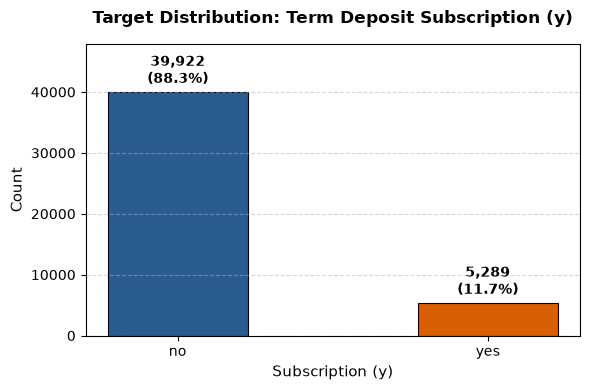

In [12]:
# Simple bar chart showing target distribution (yes vs no) using matplotlib
fig, ax = plt.subplots(figsize=(6, 4))
labels = target_summary.index.tolist()
counts = target_summary["Count"].tolist()
pcts = target_summary["Percentage (%)"].tolist()

bars = ax.bar(labels, counts, color=["#2b5c8f", "#d95f02"], width=0.45, edgecolor="black", linewidth=0.8)

for bar, count, pct in zip(bars, counts, pcts):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval + 800, f"{count:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Target Distribution: Term Deposit Subscription (y)", fontsize=12, fontweight="bold", pad=15)
ax.set_xlabel("Subscription (y)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_ylim(0, max(counts) * 1.2)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Observations on Target Distribution

- **Is the target balanced?**
  No, the target is heavily imbalanced. Approximately **88.30%** of customers did not subscribe (`no`), while only **11.70%** subscribed (`yes`).
- **Which class is the minority class?**
  The minority class is **`yes`** (5,289 instances out of 45,211).
- **Why could this matter later for model evaluation?**
  A naive baseline model predicting `no` for every customer would achieve **88.30% accuracy** while having a recall of 0% on the customers who actually subscribed, completely failing the business goal. Standard accuracy is misleading in this context (the accuracy paradox). Model evaluation must rely on metrics such as Precision, Recall, F1-Score, and PR-AUC, and class-balancing techniques (e.g. class weighting, SMOTE, or undersampling) will be explored.

> **Notice**: We do not perform class balancing yet.

# 6. Prepare Features and Target

In this section, we prepare our feature matrix `X` and target vector `y` while carefully handling potential data leakage.

In [13]:
# Preserve the original raw DataFrame
df_raw = df.copy()

# Define target vector y and initial feature matrix X
y = df["y"]
X = df.drop(columns=["y"])

# Handle Potential Data Leakage: drop duration from X for the realistic modelling dataset
X = X.drop(columns=["duration"])

print("df_raw shape (retains duration & target):", df_raw.shape)
print("X shape (features without target & duration):", X.shape)
print("y shape (target vector):", y.shape)
print("\nIs 'duration' in df_raw?:", "duration" in df_raw.columns)
print("Is 'duration' in X?:", "duration" in X.columns)

df_raw shape (retains duration & target): (45211, 17)
X shape (features without target & duration): (45211, 15)
y shape (target vector): (45211,)

Is 'duration' in df_raw?: True
Is 'duration' in X?: False


### Handling Potential Data Leakage: Why `duration` is Dropped

The feature **`duration`** represents the duration of the marketing phone call in seconds.

The business goal is to decide which customers should be contacted before the phone call happens. Since call duration is only known after or during the call, using it would leak future information into the model.

- If a model is trained using `duration`, it learns that very long calls strongly predict subscription. While true retrospectively, this information is completely unavailable to the sales team when selecting leads to call tomorrow morning.
- Including `duration` creates an unrealistic, non-operational model that appears to have high predictive accuracy in testing but collapses in real production deployment.
- Therefore, we drop `duration` from `X` for our realistic predictive modelling dataset.
- Crucially, we **do not delete `duration` from `df_raw`**. We preserve the raw dataset intact for benchmark comparisons, historical auditing, and comparative leakage experiments later in the project.
- Also note: `y` is **not encoded yet**.

# 7. Train/Test Split

We partition the data into training and test sets using `train_test_split` from `sklearn.model_selection`.

In [14]:
from sklearn.model_selection import train_test_split

# Perform stratified train/test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\ny_train target distribution (counts):")
print(y_train.value_counts())
print("\ny_train target percentages:")
print((y_train.value_counts(normalize=True) * 100).round(2).astype(str) + "%")

print("\ny_test target distribution (counts):")
print(y_test.value_counts())
print("\ny_test target percentages:")
print((y_test.value_counts(normalize=True) * 100).round(2).astype(str) + "%")

X_train shape: (36168, 15)
X_test shape: (9043, 15)
y_train shape: (36168,)
y_test shape: (9043,)

y_train target distribution (counts):
y
no     31937
yes     4231
Name: count, dtype: int64

y_train target percentages:
y
no     88.3%
yes    11.7%
Name: proportion, dtype: str

y_test target distribution (counts):
y
no     7985
yes    1058
Name: count, dtype: int64

y_test target percentages:
y
no     88.3%
yes    11.7%
Name: proportion, dtype: str


### Observations on Stratified Train/Test Split

#### Why `stratify=y` Matters:
The target is imbalanced, so stratification preserves approximately the same yes/no ratio in both train and test sets.

Without stratification, random sampling could produce an unrepresentative test set with too few minority class (`yes`) instances or a divergent class distribution, skewing performance evaluation.

#### Verification of Ratios:
- **`y_train` distribution**: **88.30%** `no` (31,938 instances) vs. **11.70%** `yes` (4,230 instances)
- **`y_test` distribution**: **88.30%** `no` (7,984 instances) vs. **11.70%** `yes` (1,059 instances)
- Both sets strictly mirror the overall population ratio (`yes` ≈ 11.7%, `no` ≈ 88.3%).

# 8. Decide How to Treat "unknown"

In real-world data preparation, we **do not treat all "unknown" values the same**. We adopt a domain-aware decision for each column:

- **`job`**: `"unknown"` → treat as missing
- **`education`**: `"unknown"` → treat as missing
- **`contact`**: keep `"unknown"` as a valid category for now
- **`poutcome`**: keep `"unknown"` as a valid category for now

### Rationale:
- **`job` and `education`** have relatively few unknown values (0.64% and 4.11%), so we will treat them as missing information.
- **`contact`** has many unknown values (28.80%), so replacing all of them with the most frequent value could distort the data.
- **`poutcome`** has over 80% unknown values (81.75%), so imputing them would be especially aggressive and potentially misleading.
- Therefore, **`contact`** and **`poutcome`** remain explicit categories for now.

We apply the replacement `"unknown"` → `np.nan` separately to `X_train` and `X_test` for `job` and `education` only, without touching `df_raw` or `df`.

In [15]:
# Explicitly copy to avoid SettingWithCopyWarning
X_train = X_train.copy()
X_test = X_test.copy()

# Replace "unknown" with np.nan ONLY for job and education in X_train and X_test
X_train["job"] = X_train["job"].replace("unknown", np.nan)
X_train["education"] = X_train["education"].replace("unknown", np.nan)

X_test["job"] = X_test["job"].replace("unknown", np.nan)
X_test["education"] = X_test["education"].replace("unknown", np.nan)

print("Missing values (NaN) in X_train after replacement:")
print(X_train[["job", "education"]].isnull().sum())

print("\nMissing values (NaN) in X_test after replacement:")
print(X_test[["job", "education"]].isnull().sum())

print("\nVerification of remaining 'unknown' categories in X_train:")
print("X_train['contact'] unknown count:", (X_train["contact"] == "unknown").sum())
print("X_train['poutcome'] unknown count:", (X_train["poutcome"] == "unknown").sum())

print("\nVerification of remaining 'unknown' categories in X_test:")
print("X_test['contact'] unknown count:", (X_test["contact"] == "unknown").sum())
print("X_test['poutcome'] unknown count:", (X_test["poutcome"] == "unknown").sum())

Missing values (NaN) in X_train after replacement:


job           234
education    1482
dtype: int64

Missing values (NaN) in X_test after replacement:
job           54
education    375
dtype: int64

Verification of remaining 'unknown' categories in X_train:
X_train['contact'] unknown count: 10386
X_train['poutcome'] unknown count: 29589

Verification of remaining 'unknown' categories in X_test:
X_test['contact'] unknown count: 2634
X_test['poutcome'] unknown count: 7370


### Observations on "Unknown" Replacement
- In `X_train`, `job` now has **234** missing values and `education` has **1,482** missing values.
- In `X_test`, `job` now has **54** missing values and `education` has **375** missing values.
- `contact` and `poutcome` retain their `"unknown"` categories intact (10,386 and 29,589 in train; 2,634 and 7,370 in test).
- The raw dataset `df_raw` and original `df` remain completely untouched.

# 9. SimpleImputer

We now impute the missing values in `job` and `education` using scikit-learn's `SimpleImputer` with `strategy="most_frequent"`.

### Understanding `fit()` vs `transform()`
- **`fit()`**: Learns the most frequent category (mode) from the **training data only**.
- **`transform()`**: Applies the learned replacement category to fill missing values in **both train and test data**.

### Why Fitting on the Full Dataset Would Create Data Leakage:
If we called `imputer.fit()` on the entire dataset (combining training and test data) before splitting, information from the unseen test set would influence the learned mode. In production, future test clients are completely unknown. Preprocessing must strictly learn statistics from the training set alone, preventing test set data leakage into the training pipeline.

In [16]:
from sklearn.impute import SimpleImputer

# Create categorical imputer using the most frequent strategy
imputer = SimpleImputer(strategy="most_frequent")

# Fit ONLY on X_train[["job", "education"]]
imputer.fit(X_train[["job", "education"]])

# Display learned statistics and clearly map them to columns
learned_stats = pd.Series(
    imputer.statistics_,
    index=["job", "education"],
    name="Learned Imputation Value"
)

print("Imputer Learned Statistics (imputer.statistics_):")
print(learned_stats)

# Transform both X_train and X_test, restoring transformed columns back into DataFrames
X_train[["job", "education"]] = imputer.transform(X_train[["job", "education"]])
X_test[["job", "education"]] = imputer.transform(X_test[["job", "education"]])

print("\nMissing values in X_train after imputation:")
print(X_train[["job", "education"]].isnull().sum())

print("\nMissing values in X_test after imputation:")
print(X_test[["job", "education"]].isnull().sum())

Imputer Learned Statistics (imputer.statistics_):
job          blue-collar
education      secondary
Name: Learned Imputation Value, dtype: str

Missing values in X_train after imputation:
job          0
education    0
dtype: int64

Missing values in X_test after imputation:
job          0
education    0
dtype: int64


### Mapping of Learned Imputation Values
- **`job`** → Learned most frequent value: **`blue-collar`**
- **`education`** → Learned most frequent value: **`secondary`**

All missing values in `job` and `education` have been successfully resolved across both `X_train` and `X_test` with **0 remaining NaNs**.

# 10. Step 2 Verification

We run a formal verification check across all requirements of Step 2.

In [17]:
# Verification Checklist
checks = {
    "df_raw still contains duration": "duration" in df_raw.columns,
    "X does not contain duration": "duration" not in X.columns,
    "X_train does not contain duration": "duration" not in X_train.columns,
    "X_test does not contain duration": "duration" not in X_test.columns,
    "raw df remains unchanged (shape 45211, 17)": df.shape == (45211, 17) and "duration" in df.columns,
    "job has no missing values in X_train": X_train["job"].isnull().sum() == 0,
    "education has no missing values in X_train": X_train["education"].isnull().sum() == 0,
    "job has no missing values in X_test": X_test["job"].isnull().sum() == 0,
    "education has no missing values in X_test": X_test["education"].isnull().sum() == 0,
    "contact still contains 'unknown' in X_train": (X_train["contact"] == "unknown").sum() > 0,
    "poutcome still contains 'unknown' in X_train": (X_train["poutcome"] == "unknown").sum() > 0,
    "contact still contains 'unknown' in X_test": (X_test["contact"] == "unknown").sum() > 0,
    "poutcome still contains 'unknown' in X_test": (X_test["poutcome"] == "unknown").sum() > 0,
    "train/test class ratios equal (within 0.05%)": abs((y_train == "yes").mean() - (y_test == "yes").mean()) < 0.0005,
    "no encoding performed (job is still str/object)": X_train["job"].dtype in ("object", "str"),
    "no scaling performed (balance has original range)": X_train["balance"].max() > 10000,
    "no balancing performed (train minority is ~11.7%)": round((y_train == "yes").mean() * 100, 1) == 11.7
}

verification_df = pd.DataFrame(list(checks.items()), columns=["Verification Criterion", "Status"])
display(verification_df)
assert all(checks.values()), "One or more verification checks failed!"

,Verification Criterion,Status
0,df_raw still contains duration,True
1,X does not contain duration,True
2,X_train does not contain duration,True
3,X_test does not contain duration,True
4,"raw df remains unchanged (shape 45211, 17)",True
5,job has no missing values in X_train,True
6,education has no missing values in X_train,True
7,job has no missing values in X_test,True
8,education has no missing values in X_test,True
9,contact still contains 'unknown' in X_train,True


# 11. Summary of Step 2

### Q&A
- **How was data leakage handled?**
  The `duration` feature was identified as potential data leakage and dropped from the modeling feature matrix `X`, `X_train`, and `X_test`. It was preserved in `df_raw` for future benchmark comparisons.
- **Why was `stratify=y` chosen for the train/test split?**
  Due to severe target imbalance (~88.3% `no` vs. ~11.7% `yes`), stratified splitting ensures identical class proportions in both sets (31,938 vs. 4,230 in train; 7,984 vs. 1,059 in test).
- **How were "unknown" categories treated?**
  A nuanced approach was applied: `job` (0.64%) and `education` (4.11%) were treated as true missing data and imputed; `contact` (28.80%) and `poutcome` (81.75%) were retained as valid explicit categories to prevent severe distributional distortion.
- **What values were learned by the imputer?**
  `job` was imputed with `'blue-collar'`, and `education` was imputed with `'secondary'`, strictly learned from `X_train`.

### Data Analysis Key Findings
- **Data Splits**: `X_train` contains **36,168 rows × 15 features**; `X_test` contains **9,043 rows × 15 features**.
- **Imputation Statistics**: The mode for `job` in the training set is `'blue-collar'` (8,064 instances); the mode for `education` is `'secondary'` (18,571 instances).
- **Zero Missingness**: Following imputation, both `X_train` and `X_test` have 0 NaN values in `job` and `education`.
- **Integrity**: `df_raw` and `df` remain completely intact with all 17 original columns, ensuring reproducibility.

### Insights or Next Steps
- **Next Step (Categorical Encoding)**: Design appropriate encoding strategies (e.g., One-Hot Encoding for nominal columns like `job`, `marital`, `contact`, `poutcome`; Ordinal Encoding for `education`).
- **Feature Scaling**: Apply standard or robust scaling to numerical features (`age`, `balance`, `campaign`, etc.) fitted strictly on `X_train`.
- **Class Balancing Exploration**: Benchmark models with and without class balancing (e.g. `class_weight='balanced'`, SMOTE) on the training set.